In [ ]:
# 1.Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import Food101
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 2. Super-Category Mapping 
SUPER_CATEGORIES = {
    0: ("Pies & Pastries",       ["apple_pie", "baklava", "cannoli", "churros"]),
    1: ("Cakes & Desserts",      ["cheesecake", "chocolate_cake", "cup_cakes", "waffles", "donuts"]),
    2: ("Meat & Seafood",        ["steak", "baby_back_ribs", "chicken_wings", "shrimp_and_grits", "sashimi", "oysters"]),
    3: ("Fast Food & Snacks",    ["pizza", "hamburger", "hot_dog", "nachos", "french_fries"]),
    4: ("Noodles, Rice & Bread", ["ramen", "pad_thai", "fried_rice", "bread_pudding", "hummus"]),
    5: ("Soups & Stews",         ["pho", "clam_chowder", "french_onion_soup", "lobster_bisque"]),
    6: ("Salads & Vegetables",   ["caesar_salad", "edamame", "guacamole", "caprese_salad"]),
    7: ("Breakfast & Eggs",      ["eggs_benedict", "pancakes", "french_toast", "omelette"]),
}


SUPER_CATEGORY_NAMES = [SUPER_CATEGORIES[i][0] for i in range(8)]
NUM_CLASSES = 8

CLASS_TO_SUPER = {}
for super_idx, (_, food_classes) in SUPER_CATEGORIES.items():
    for cls in food_classes:
        CLASS_TO_SUPER[cls] = super_idx




In [ ]:
#3. Custom Dataset Wrapper 
class Food101SuperCategory(torch.utils.data.Dataset):
    """Same wrapper as Baseline — filters Food-101 to 8 super-categories."""
    def __init__(self, root, split, transform):
        self.base = Food101(root=root, split=split, transform=transform, download=True)
        food101_classes = self.base.classes
        self.label_map = {
            i: CLASS_TO_SUPER.get(name, -1)
            for i, name in enumerate(food101_classes)
        }
        self.valid_indices = [
            i for i, lbl in enumerate(self.base._labels)
            if self.label_map[lbl] != -1
        ]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        image, orig_label = self.base[self.valid_indices[idx]]
        return image, self.label_map[orig_label]




In [ ]:
#4. Improved Hyperparameters 

IMAGE_SIZE    = 128
BATCH_SIZE    = 64
LEARNING_RATE = 0.0005
NUM_EPOCHS    = 30
LR_STEP_SIZE  = 7      
LR_GAMMA      = 0.5    # multiply LR by this factor at each step




In [ ]:
# 5. Improved Transforms (heavier augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 20, IMAGE_SIZE + 20)),  # slight oversize
    transforms.RandomCrop(IMAGE_SIZE),                       
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,    # colour variation
                           saturation=0.3, hue=0.1),
    transforms.RandomRotation(degrees=15),                   # small rotation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])




In [ ]:
#6. Load Dataset
print("Loading Food-101 with 8 super-categories...")

train_dataset = Food101SuperCategory(root="./data", split="train", transform=train_transform)
test_dataset  = Food101SuperCategory(root="./data", split="test",  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")




Loading Food-101 with 8 super-categories...


100%|██████████| 5.00G/5.00G [04:37<00:00, 18.0MB/s]


Training samples : 27750
Test samples     : 9250


In [ ]:
# 7. Improved CNN Architecture 
class ImprovedCNN(nn.Module):
    
    def __init__(self, num_classes=8):
        super(ImprovedCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4 
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = ImprovedCNN(num_classes=NUM_CLASSES).to(device)
print("\nImproved CNN Architecture:")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")





Improved CNN Architecture:
ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=T

In [ ]:
# 8. Loss, Optimizer & Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# StepLR: multiply LR by LR_GAMMA every LR_STEP_SIZE epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)



In [ ]:
# 9. Train 
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += outputs.argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    return running_loss / total, 100.0 * correct / total




In [ ]:
# 10. Training Loop
train_losses, train_accs = [], []
test_losses,  test_accs  = [], []
lr_history = []

print("\n" + "="*65)
print("  Improved CNN Training  (8 super-categories, Food-101)")
print("="*65)

for epoch in range(1, NUM_EPOCHS + 1):
    current_lr = optimizer.param_groups[0]["lr"]
    lr_history.append(current_lr)

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(tr_loss);  train_accs.append(tr_acc)
    test_losses.append(te_loss);   test_accs.append(te_acc)

    scheduler.step()   # update learning rate

    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}]  LR: {current_lr:.5f}  |  "
          f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.2f}%  |  "
          f"Test Loss: {te_loss:.4f}  Test Acc: {te_acc:.2f}%")

print("="*65)
print("Training complete.")





  Improved CNN Training  (8 super-categories, Food-101)
Epoch [01/30]  LR: 0.00050  |  Train Loss: 2.0091  Train Acc: 22.14%  |  Test Loss: 1.8511  Test Acc: 31.46%
Epoch [02/30]  LR: 0.00050  |  Train Loss: 1.8906  Train Acc: 27.38%  |  Test Loss: 1.7928  Test Acc: 32.46%
Epoch [03/30]  LR: 0.00050  |  Train Loss: 1.8375  Train Acc: 30.01%  |  Test Loss: 1.7187  Test Acc: 37.20%
Epoch [04/30]  LR: 0.00050  |  Train Loss: 1.7927  Train Acc: 32.52%  |  Test Loss: 1.6638  Test Acc: 38.63%
Epoch [05/30]  LR: 0.00050  |  Train Loss: 1.7432  Train Acc: 34.74%  |  Test Loss: 1.6382  Test Acc: 39.39%
Epoch [06/30]  LR: 0.00050  |  Train Loss: 1.6977  Train Acc: 36.74%  |  Test Loss: 1.6760  Test Acc: 38.56%
Epoch [07/30]  LR: 0.00050  |  Train Loss: 1.6563  Train Acc: 38.89%  |  Test Loss: 1.5423  Test Acc: 43.44%
Epoch [08/30]  LR: 0.00025  |  Train Loss: 1.5789  Train Acc: 42.10%  |  Test Loss: 1.4290  Test Acc: 49.06%
Epoch [09/30]  LR: 0.00025  |  Train Loss: 1.5495  Train Acc: 43.74%  |

In [ ]:
# 11. Save Model 
torch.save(model.state_dict(), "improved_cnn.pth")
print("Model saved → improved_cnn.pth")

Model saved → improved_cnn.pth


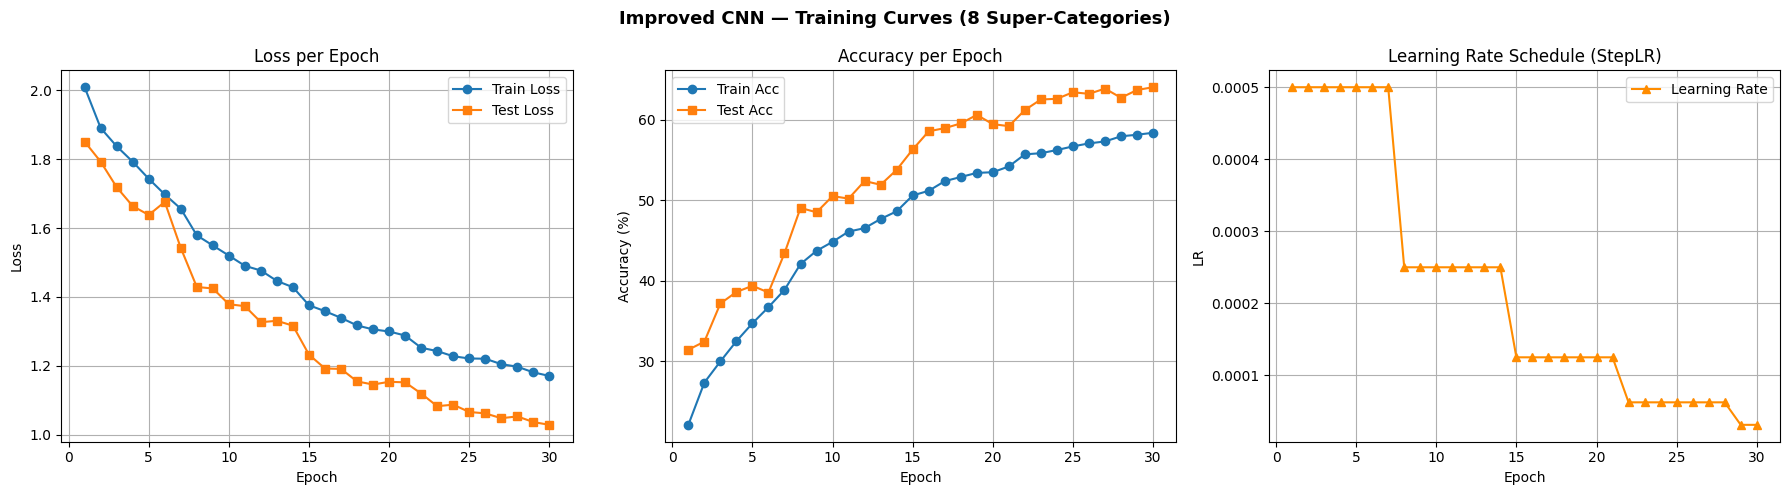

Saved → improved_training_curves.png


In [ ]:
#12. Training Curves
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Improved CNN — Training Curves (8 Super-Categories)",
             fontsize=13, fontweight="bold")

axes[0].plot(epochs_range, train_losses, label="Train Loss", marker="o")
axes[0].plot(epochs_range, test_losses,  label="Test Loss",  marker="s")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, train_accs, label="Train Acc", marker="o")
axes[1].plot(epochs_range, test_accs,  label="Test Acc",  marker="s")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs_range, lr_history, label="Learning Rate", color="darkorange", marker="^")
axes[2].set_title("Learning Rate Schedule (StepLR)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig("improved_training_curves.png", dpi=150)
plt.show()
print("Saved → improved_training_curves.png")


In [ ]:
#13. Detailed Evaluation
print("\nRunning full evaluation on test set...")
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=SUPER_CATEGORY_NAMES,
                             zero_division=0))

final_acc = 100.0 * (all_preds == all_labels).sum() / len(all_labels)
print(f"Overall Test Accuracy: {final_acc:.2f}%")



Running full evaluation on test set...

Classification Report:
                       precision    recall  f1-score   support

      Pies & Pastries       0.56      0.48      0.52      1000
     Cakes & Desserts       0.56      0.74      0.64      1250
       Meat & Seafood       0.67      0.68      0.67      1500
   Fast Food & Snacks       0.64      0.58      0.61      1250
Noodles, Rice & Bread       0.65      0.52      0.58      1250
        Soups & Stews       0.69      0.84      0.76      1000
  Salads & Vegetables       0.77      0.79      0.78      1000
     Breakfast & Eggs       0.61      0.48      0.54      1000

             accuracy                           0.64      9250
            macro avg       0.64      0.64      0.64      9250
         weighted avg       0.64      0.64      0.64      9250

Overall Test Accuracy: 64.04%


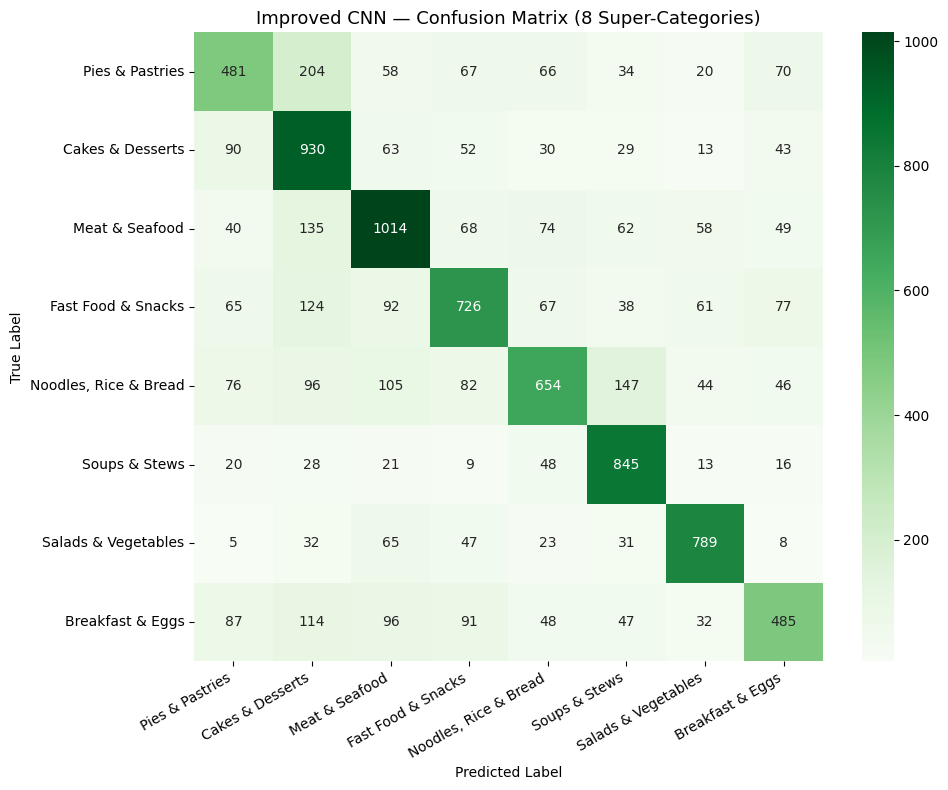

Saved → improved_confusion_matrix.png


In [ ]:
# 14. Confusion Matrix 
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=SUPER_CATEGORY_NAMES,
            yticklabels=SUPER_CATEGORY_NAMES)
plt.title("Improved CNN — Confusion Matrix (8 Super-Categories)", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("improved_confusion_matrix.png", dpi=150)
plt.show()
print("Saved → improved_confusion_matrix.png")

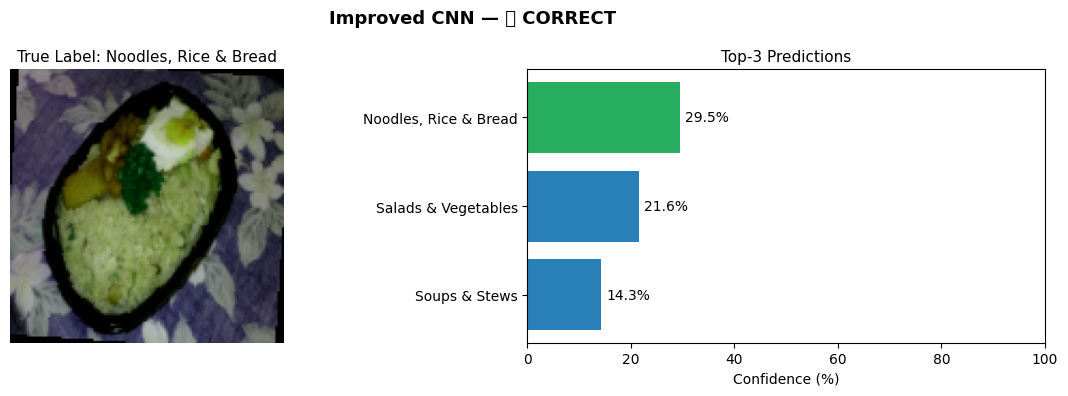

In [ ]:
# Test on a random training image 
import random

model.eval()
rand_idx = random.randint(0, len(train_dataset) - 1)
image_tensor, true_label = train_dataset[rand_idx]

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])
img_display = image_tensor * std[:, None, None] + mean[:, None, None]
img_display = img_display.permute(1, 2, 0).clamp(0, 1).numpy()

with torch.no_grad():
    outputs = model(image_tensor.unsqueeze(0).to(device))
    probs   = torch.softmax(outputs, dim=1)[0]
    top3    = probs.topk(3)

top3_names  = [SUPER_CATEGORY_NAMES[i] for i in top3.indices.cpu().numpy()]
top3_scores = top3.values.cpu().numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_display)
axes[0].axis("off")
axes[0].set_title(f"True Label: {SUPER_CATEGORY_NAMES[true_label]}", fontsize=11)

colors = ["#27ae60" if top3.indices[0].item() == true_label else "#e74c3c"] + ["#2980b9"] * 2
axes[1].barh(top3_names[::-1], top3_scores[::-1], color=colors[::-1])
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Confidence (%)")
axes[1].set_title("Top-3 Predictions", fontsize=11)
for j, (name, score) in enumerate(zip(top3_names[::-1], top3_scores[::-1])):
    axes[1].text(score + 1, j, f"{score:.1f}%", va="center", fontsize=10)

result = "CORRECT" if top3.indices[0].item() == true_label else f"WRONG (true: {SUPER_CATEGORY_NAMES[true_label]})"
plt.suptitle(f"Improved CNN — {result}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Upload a food image to classify:


Saving chocolate cake.jfif to chocolate cake.jfif


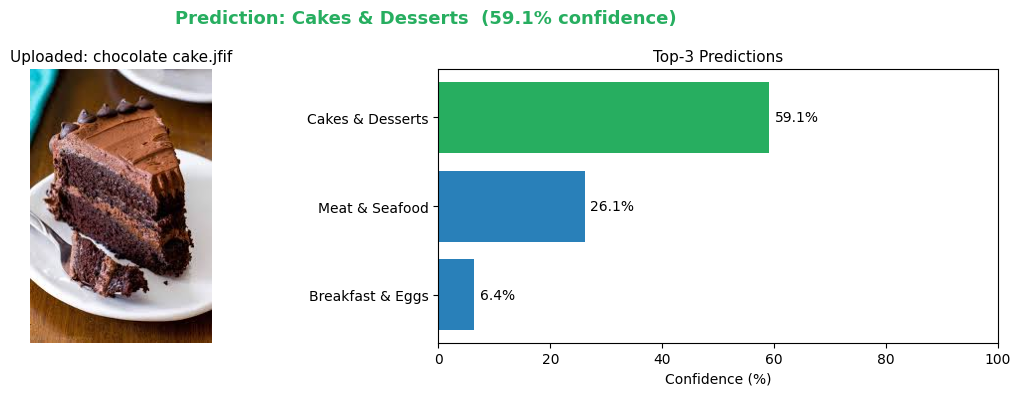


Top-3 Predictions for 'chocolate cake.jfif':
  1. Cakes & Desserts          59.05%
  2. Meat & Seafood            26.12%
  3. Breakfast & Eggs          6.36%


In [ ]:
# 16. Interactive Single-Image Prediction 


from google.colab import files
from PIL import Image
import io

print("\nUpload a food image to classify:")
uploaded = files.upload()

for filename, file_bytes in uploaded.items():
    img = Image.open(io.BytesIO(file_bytes)).convert("RGB")

    preprocess = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs   = torch.softmax(outputs, dim=1)[0]
        top3    = probs.topk(3)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(f"Uploaded: {filename}", fontsize=11)

    top3_names  = [SUPER_CATEGORY_NAMES[i] for i in top3.indices.cpu().numpy()]
    top3_scores = top3.values.cpu().numpy() * 100

    colors = ["#27ae60" if i == 0 else "#2980b9" for i in range(3)]
    axes[1].barh(top3_names[::-1], top3_scores[::-1], color=colors[::-1])
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel("Confidence (%)")
    axes[1].set_title("Top-3 Predictions", fontsize=11)
    for j, (name, score) in enumerate(zip(top3_names[::-1], top3_scores[::-1])):
        axes[1].text(score + 1, j, f"{score:.1f}%", va="center", fontsize=10)

    plt.suptitle(
        f"Prediction: {top3_names[0]}  ({top3_scores[0]:.1f}% confidence)",
        fontsize=13, fontweight="bold", color="#27ae60"
    )
    plt.tight_layout()
    plt.show()

    print(f"\nTop-3 Predictions for '{filename}':")
    for i, (name, score) in enumerate(zip(top3_names, top3_scores), 1):
        print(f"  {i}. {name:<25} {score:.2f}%")